# Przewidywanie jakości wina — Baseline (EDA + model bazowy)

**Sekcja 2 wymagań:** eksploracja danych (EDA) → preprocessing → trening modelu bazowego → ewaluacja.

**Problem:** klasyfikacja binarna `quality >= 6 → "dobre" (1)`, inaczej `"słabe" (0)`.

**Autor pakietu:** s27492 · **Dataset:** `data/01_raw/winequality-red.csv`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)
import joblib

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 1. Wczytanie danych

In [2]:
DATA_PATH = Path("..") / "data" / "01_raw" / "winequality-red.csv"
df = pd.read_csv(DATA_PATH)
print("Wymiary:", df.shape)
df.head()

Wymiary: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


## 2. Eksploracyjna analiza danych (EDA)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
# Jakość danych: braki i duplikaty
print("Braki danych (suma):", int(df.isnull().sum().sum()))
print("Duplikaty wierszy:", int(df.duplicated().sum()))

Braki danych (suma): 0
Duplikaty wierszy: 240


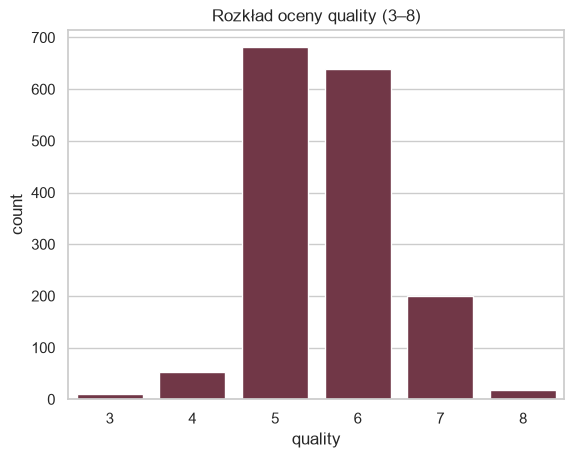

In [6]:
# Rozkład oryginalnej oceny quality
ax = sns.countplot(x="quality", data=df, color="#7b2d43")
ax.set_title("Rozkład oceny quality (3–8)")
plt.show()

0 = słabe, 1 = dobre
target
0    744
1    855
Name: count, dtype: int64
Udział 'dobrych': 53.5%


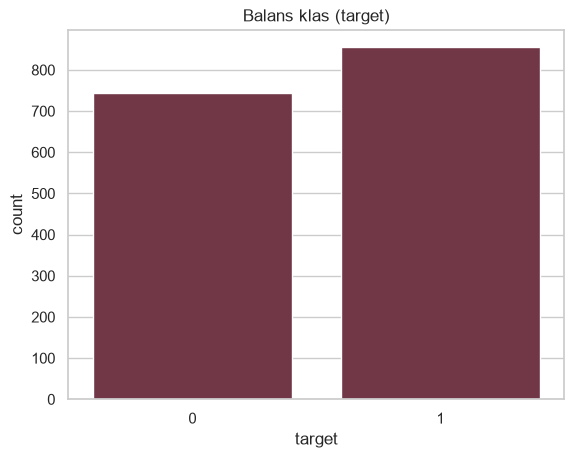

In [7]:
# Definicja targetu binarnego i balans klas
df["target"] = (df["quality"] >= 6).astype(int)
balance = df["target"].value_counts().sort_index()
print("0 = słabe, 1 = dobre")
print(balance)
print(f"Udział 'dobrych': {100 * df['target'].mean():.1f}%")
sns.countplot(x="target", data=df, color="#7b2d43").set_title("Balans klas (target)")
plt.show()

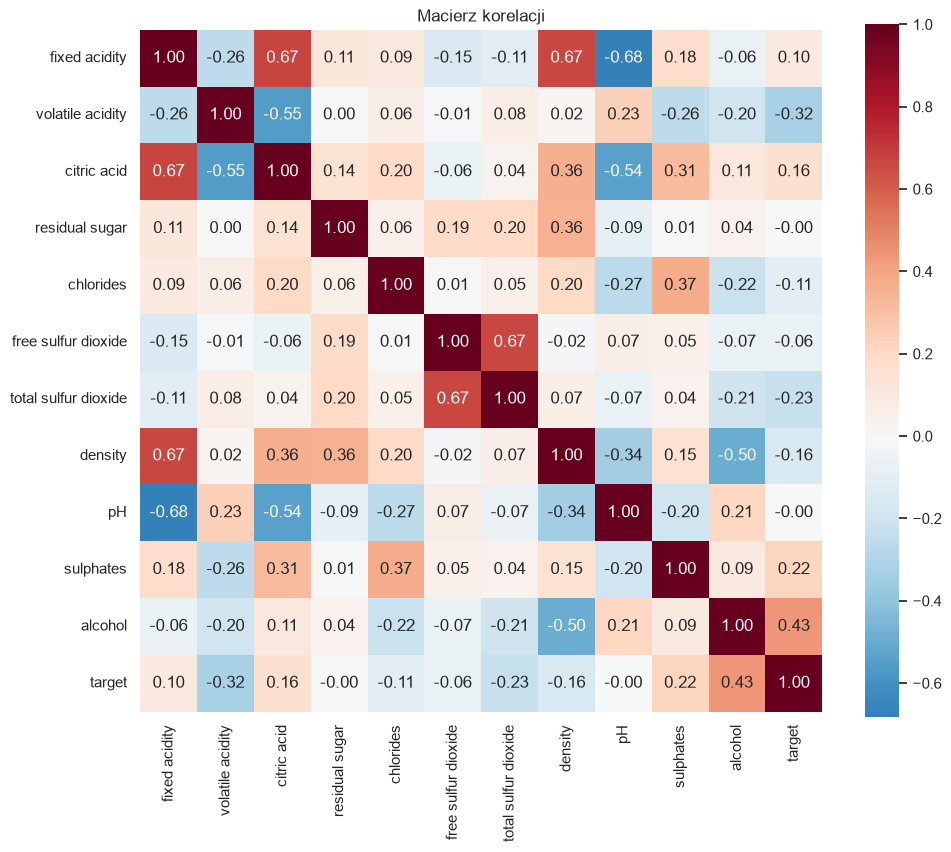

In [8]:
# Mapa korelacji cech
plt.figure(figsize=(11, 9))
corr = df.drop(columns=["quality"]).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Macierz korelacji")
plt.show()

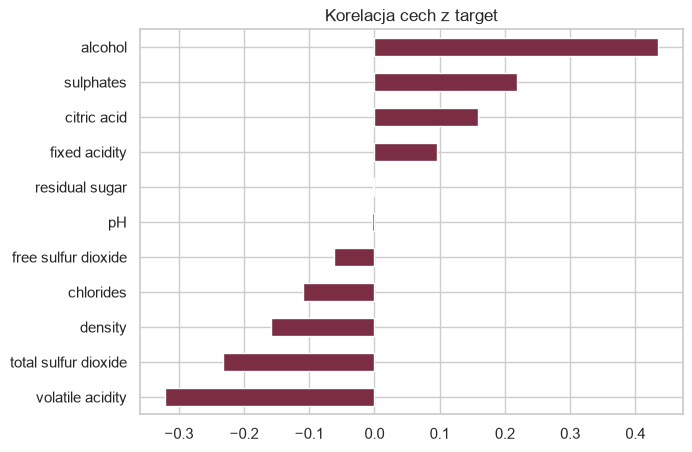

volatile acidity       -0.321441
total sulfur dioxide   -0.231963
density                -0.159110
chlorides              -0.109494
free sulfur dioxide    -0.061757
pH                     -0.003264
residual sugar         -0.002160
fixed acidity           0.095093
citric acid             0.159129
sulphates               0.218072
alcohol                 0.434751
Name: target, dtype: float64

In [9]:
# Korelacja cech z targetem (posortowana)
corr_target = df.drop(columns=["quality"]).corr()["target"].drop("target").sort_values()
corr_target.plot(kind="barh", color="#7b2d43", figsize=(7, 5), title="Korelacja cech z target")
plt.show()
corr_target

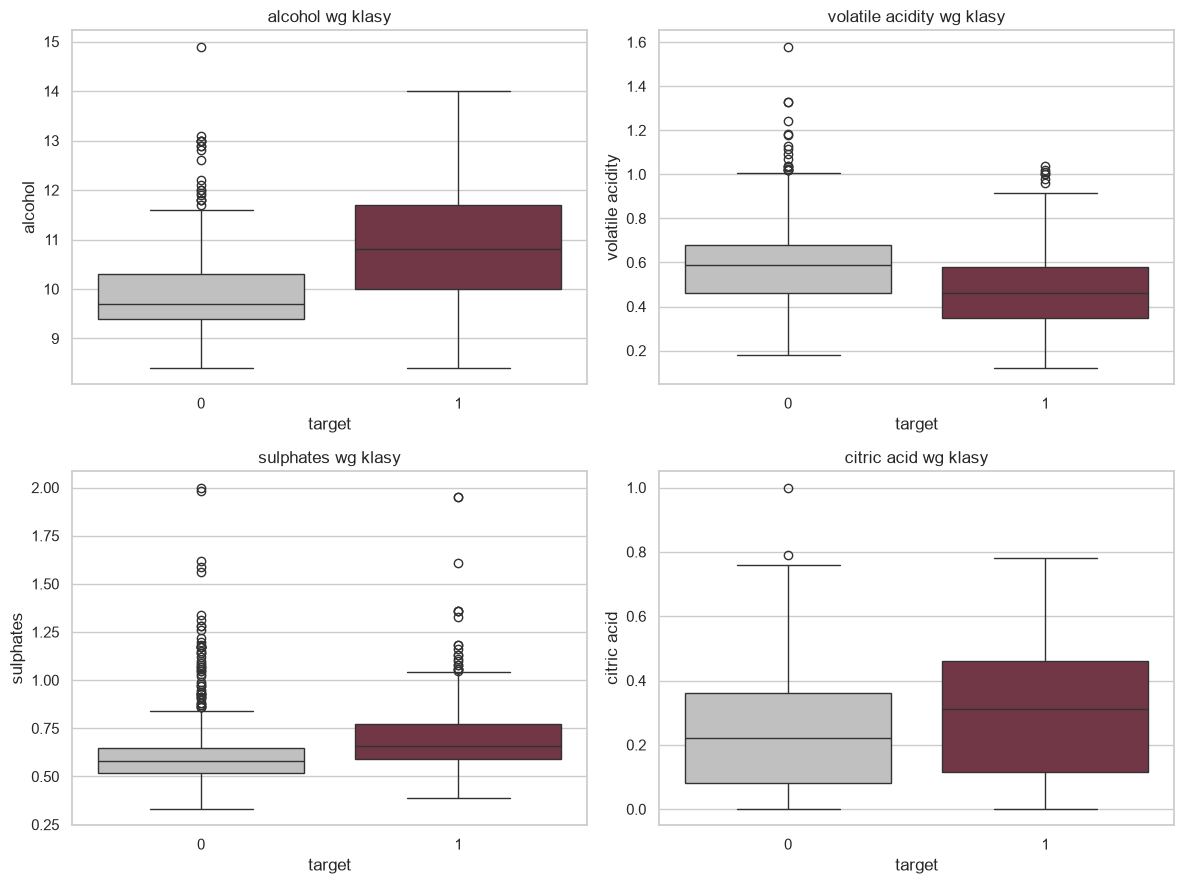

In [10]:
# Rozkłady najważniejszych cech względem klasy
key_features = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, col in zip(axes.ravel(), key_features):
    sns.boxplot(x="target", y=col, hue="target", data=df, ax=ax,
                palette=["#c0c0c0", "#7b2d43"], legend=False)
    ax.set_title(f"{col} wg klasy")
plt.tight_layout()
plt.show()

## 3. Preprocessing

- usunięcie duplikatów,
- rozdzielenie cech (`X`) i celu (`y`),
- podział train/test (stratyfikowany),
- standaryzacja cech (`StandardScaler`).

In [11]:
data = df.drop_duplicates().reset_index(drop=True)
print("Po usunięciu duplikatów:", data.shape)

FEATURES = [c for c in data.columns if c not in ("quality", "target")]
X = data[FEATURES]
y = data["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Po usunięciu duplikatów: (1359, 13)
Train: (1087, 11) Test: (272, 11)


## 4. Model bazowy — Regresja logistyczna

In [12]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:, 1]

## 5. Ewaluacja

In [13]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}
for k, v in metrics.items():
    print(f"{k:>10}: {v:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["słabe", "dobre"]))

  accuracy: 0.735
 precision: 0.761
    recall: 0.729
        f1: 0.745
   roc_auc: 0.812

              precision    recall  f1-score   support

       słabe       0.71      0.74      0.73       128
       dobre       0.76      0.73      0.74       144

    accuracy                           0.74       272
   macro avg       0.73      0.74      0.73       272
weighted avg       0.74      0.74      0.74       272



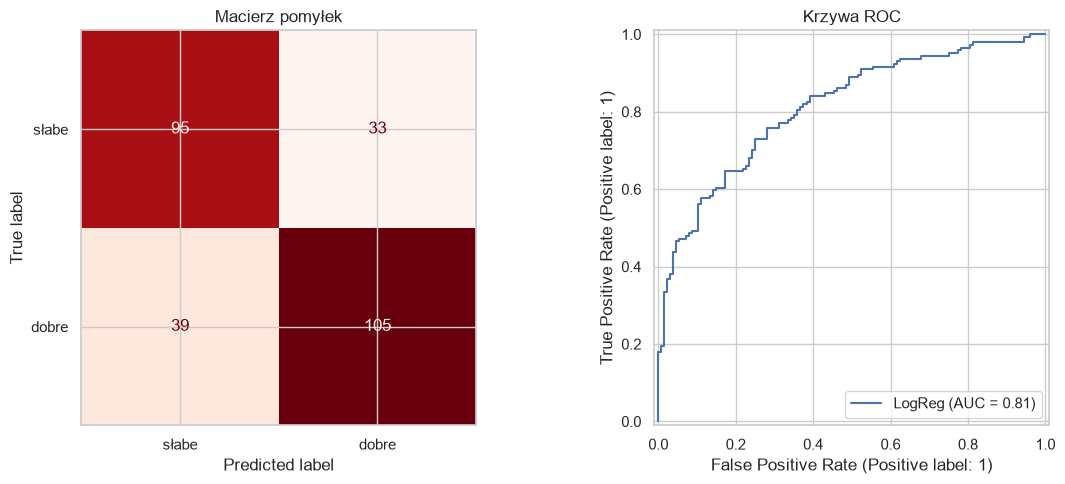

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=["słabe", "dobre"]
).plot(ax=axes[0], cmap="Reds", colorbar=False)
axes[0].set_title("Macierz pomyłek")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="LogReg")
axes[1].set_title("Krzywa ROC")
plt.tight_layout()
plt.show()

## 6. Zapis modelu bazowego (mock dla zespołu)

Zapisujemy wytrenowany `scaler` + `model` jako artefakt baseline. Dzięki temu osoby
od pipeline'u (s26681) i serwowania (27100) mogą pracować na realnym modelu, zanim
powstanie finalny model w MLflow Model Registry.

In [15]:
MODELS_DIR = Path("..") / "data" / "06_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

artifact = {"scaler": scaler, "model": model, "features": FEATURES, "metrics": metrics}
joblib.dump(artifact, MODELS_DIR / "baseline_logreg.pkl")
print("Zapisano:", MODELS_DIR / "baseline_logreg.pkl")

Zapisano: ..\data\06_models\baseline_logreg.pkl


## 7. Wnioski

- Model bazowy (regresja logistyczna) ustala punkt odniesienia dla kolejnych etapów.
- Najsilniej z jakością korelują: `alcohol` (+), `volatile acidity` (−), `sulphates` (+).
- Kolejne kroki (s26681): AutoML + strojenie hiperparametrów powinny poprawić F1/ROC-AUC.
- *Uzupełnij obserwacje liczbowe po uruchomieniu notebooka.*